# Round 5 Trade-Flow Alpha Research

This notebook treats public trades as informed-flow events and measures future mid-price markouts. The goal is alpha extraction from order-flow patterns, not trader-ID reconstruction.

In [1]:

from pathlib import Path
from itertools import combinations, product
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from sklearn.decomposition import PCA
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.vector_ar.vecm import coint_johansen

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid", context="notebook")

BASE = Path.cwd()
if not (BASE / "prices_round_5_day_2.csv").exists():
    BASE = BASE / "ROUND_5"

DAYS = [2, 3, 4]
DAY_OFFSET = 1_000_000

GROUPS = {
    "GALAXY": ["GALAXY_SOUNDS_DARK_MATTER", "GALAXY_SOUNDS_BLACK_HOLES", "GALAXY_SOUNDS_PLANETARY_RINGS", "GALAXY_SOUNDS_SOLAR_WINDS", "GALAXY_SOUNDS_SOLAR_FLAMES"],
    "SLEEP": ["SLEEP_POD_SUEDE", "SLEEP_POD_LAMB_WOOL", "SLEEP_POD_POLYESTER", "SLEEP_POD_NYLON", "SLEEP_POD_COTTON"],
    "MICROCHIP": ["MICROCHIP_CIRCLE", "MICROCHIP_OVAL", "MICROCHIP_SQUARE", "MICROCHIP_RECTANGLE", "MICROCHIP_TRIANGLE"],
    "PEBBLES": ["PEBBLES_XS", "PEBBLES_S", "PEBBLES_M", "PEBBLES_L", "PEBBLES_XL"],
    "ROBOT": ["ROBOT_VACUUMING", "ROBOT_MOPPING", "ROBOT_DISHES", "ROBOT_LAUNDRY", "ROBOT_IRONING"],
    "UV_VISOR": ["UV_VISOR_YELLOW", "UV_VISOR_AMBER", "UV_VISOR_ORANGE", "UV_VISOR_RED", "UV_VISOR_MAGENTA"],
    "TRANSLATOR": ["TRANSLATOR_SPACE_GRAY", "TRANSLATOR_ASTRO_BLACK", "TRANSLATOR_ECLIPSE_CHARCOAL", "TRANSLATOR_GRAPHITE_MIST", "TRANSLATOR_VOID_BLUE"],
    "PANEL": ["PANEL_1X2", "PANEL_2X2", "PANEL_1X4", "PANEL_2X4", "PANEL_4X4"],
    "OXYGEN": ["OXYGEN_SHAKE_MORNING_BREATH", "OXYGEN_SHAKE_EVENING_BREATH", "OXYGEN_SHAKE_MINT", "OXYGEN_SHAKE_CHOCOLATE", "OXYGEN_SHAKE_GARLIC"],
    "SNACKPACK": ["SNACKPACK_CHOCOLATE", "SNACKPACK_VANILLA", "SNACKPACK_PISTACHIO", "SNACKPACK_STRAWBERRY", "SNACKPACK_RASPBERRY"],
}
PRODUCT_TO_GROUP = {p: g for g, ps in GROUPS.items() for p in ps}
PRODUCTS = [p for ps in GROUPS.values() for p in ps]

def short(name):
    for prefix in ["GALAXY_SOUNDS_", "SLEEP_POD_", "MICROCHIP_", "PEBBLES_", "ROBOT_", "UV_VISOR_", "TRANSLATOR_", "PANEL_", "OXYGEN_SHAKE_", "SNACKPACK_"]:
        name = name.replace(prefix, "")
    return name

def load_prices():
    frames = []
    for day in DAYS:
        df = pd.read_csv(BASE / f"prices_round_5_day_{day}.csv", sep=";")
        df["global_ts"] = df["timestamp"] + (day - DAYS[0]) * DAY_OFFSET
        frames.append(df)
    prices = pd.concat(frames, ignore_index=True)
    prices["group"] = prices["product"].map(PRODUCT_TO_GROUP)
    mids = prices.pivot_table(index="global_ts", columns="product", values="mid_price").sort_index().ffill()
    return prices, mids

def load_trades():
    frames = []
    for day in DAYS:
        df = pd.read_csv(BASE / f"trades_round_5_day_{day}.csv", sep=";")
        df["day"] = day
        df["global_ts"] = df["timestamp"] + (day - DAYS[0]) * DAY_OFFSET
        frames.append(df)
    trades = pd.concat(frames, ignore_index=True)
    trades["group"] = trades["symbol"].map(PRODUCT_TO_GROUP)
    return trades

def fast_adf(x, max_points=6000):
    x = pd.Series(x).replace([np.inf, -np.inf], np.nan).dropna()
    if len(x) > max_points:
        x = x.iloc[:: max(1, len(x) // max_points)]
    if len(x) < 50 or x.nunique() < 4:
        return np.nan
    try:
        return adfuller(x, maxlag=8, autolag=None)[1]
    except Exception:
        return np.nan

def zscore(s, window=500):
    s = pd.Series(s)
    mu = s.rolling(window, min_periods=window//3).mean()
    sd = s.rolling(window, min_periods=window//3).std()
    return (s - mu) / sd

prices, mids = load_prices()
rets_1 = np.log(mids).diff()
rets_10 = np.log(mids.iloc[::10]).diff().dropna()
print(prices.shape, mids.shape)

trades = load_trades()
print(trades.shape)

(1500000, 19) (30000, 50)
(35385, 10)


## 1. Enrich Trades With Quote Context

In [2]:

quotes = prices[["global_ts", "product", "bid_price_1", "ask_price_1", "mid_price"]].rename(columns={"product": "symbol"})
tr = trades.merge(quotes, on=["global_ts", "symbol"], how="left")
tr["side"] = np.select(
    [np.isclose(tr.price, tr.ask_price_1), np.isclose(tr.price, tr.bid_price_1)],
    ["buy", "sell"],
    default="other",
)
tr["edge_to_mid"] = tr.price - tr.mid_price
tr["abs_edge_to_mid"] = tr.edge_to_mid.abs()
display(tr.head())
display(tr.groupby(["group", "side"]).agg(prints=("price","size"), avg_qty=("quantity","mean"), avg_abs_edge=("abs_edge_to_mid","mean")).reset_index())


,timestamp,buyer,seller,symbol,currency,price,quantity,day,global_ts,group,bid_price_1,ask_price_1,mid_price,side,edge_to_mid,abs_edge_to_mid
0,1700,NaN,NaN,GALAXY_SOUNDS_BLACK_HOLES,XIRECS,9969.0,4,2,1700,GALAXY,9969,9982,9975.5,sell,-6.5,6.5
1,1700,NaN,NaN,GALAXY_SOUNDS_DARK_MATTER,XIRECS,9977.0,4,2,1700,GALAXY,9977,9989,9983.0,sell,-6.0,6.0
2,1700,NaN,NaN,GALAXY_SOUNDS_PLANETARY_RINGS,XIRECS,9957.0,4,2,1700,GALAXY,9957,9970,9963.5,sell,-6.5,6.5
3,1700,NaN,NaN,GALAXY_SOUNDS_SOLAR_FLAMES,XIRECS,9976.0,4,2,1700,GALAXY,9976,9989,9982.5,sell,-6.5,6.5
4,1700,NaN,NaN,GALAXY_SOUNDS_SOLAR_WINDS,XIRECS,10084.0,4,2,1700,GALAXY,10084,10097,10090.5,sell,-6.5,6.5


,group,side,prints,avg_qty,avg_abs_edge
0,GALAXY,buy,1790,2.458101,6.888547
1,GALAXY,sell,1875,2.466667,6.850400
2,MICROCHIP,buy,1500,2.000000,4.393333
3,MICROCHIP,sell,1345,1.929368,4.433829
4,OXYGEN,buy,1790,2.458101,6.463408
5,OXYGEN,sell,1875,2.466667,6.419733
6,PANEL,buy,1790,2.458101,4.704190
7,PANEL,sell,1875,2.466667,4.681600
8,PEBBLES,buy,1605,3.529595,6.447975
9,PEBBLES,sell,1615,3.560372,6.444272


## 2. Future Markouts By Product And Group

,group,side,quantity,lookahead,events,mean_markout,median_markout,hit_rate,t
144,PANEL,buy,3,100,380,1.530263,1.50,0.565789,3.078669
287,SLEEP,buy,2,25000,440,21.825000,19.00,0.552273,2.566624
256,ROBOT,sell,1,10000,450,11.268889,13.00,0.553333,2.430318
436,UV_VISOR,buy,3,10000,380,12.000000,6.75,0.528947,2.329200
266,ROBOT,sell,3,1000,475,3.310526,2.50,0.524211,2.276819
404,TRANSLATOR,sell,2,1000,525,3.189524,2.00,0.531429,2.261966
264,ROBOT,sell,3,100,475,1.275789,-0.00,0.444211,2.210191
72,MICROCHIP,sell,2,100,500,1.444000,0.75,0.520000,2.195974
374,TRANSLATOR,buy,1,1000,500,3.057000,3.50,0.536000,2.122919
286,SLEEP,buy,2,10000,440,10.869318,11.25,0.538636,2.121855


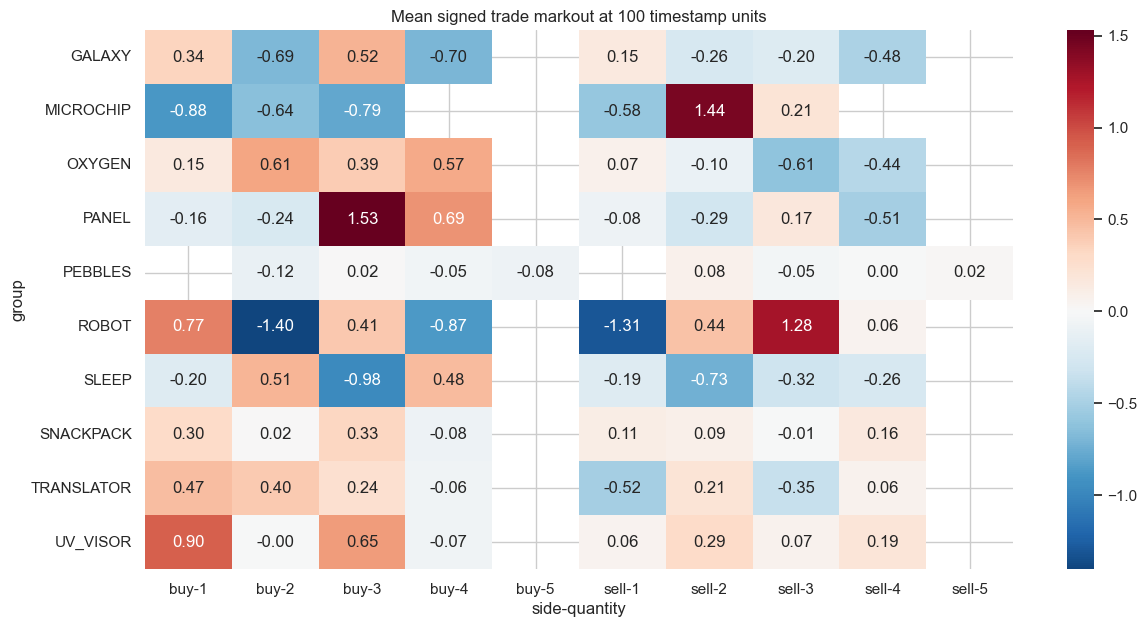

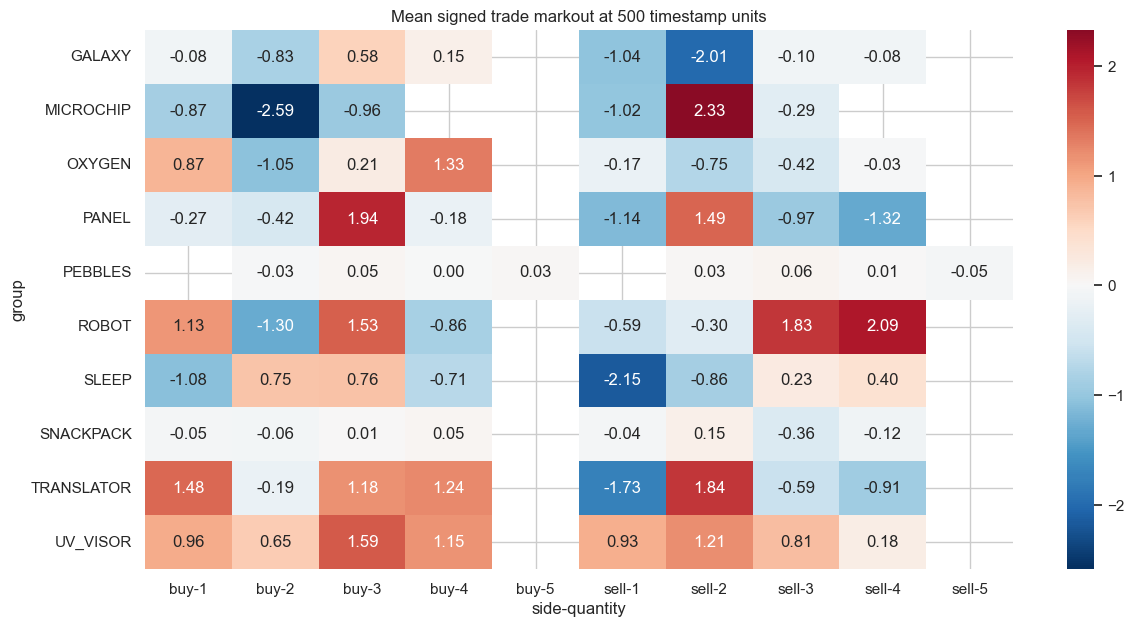

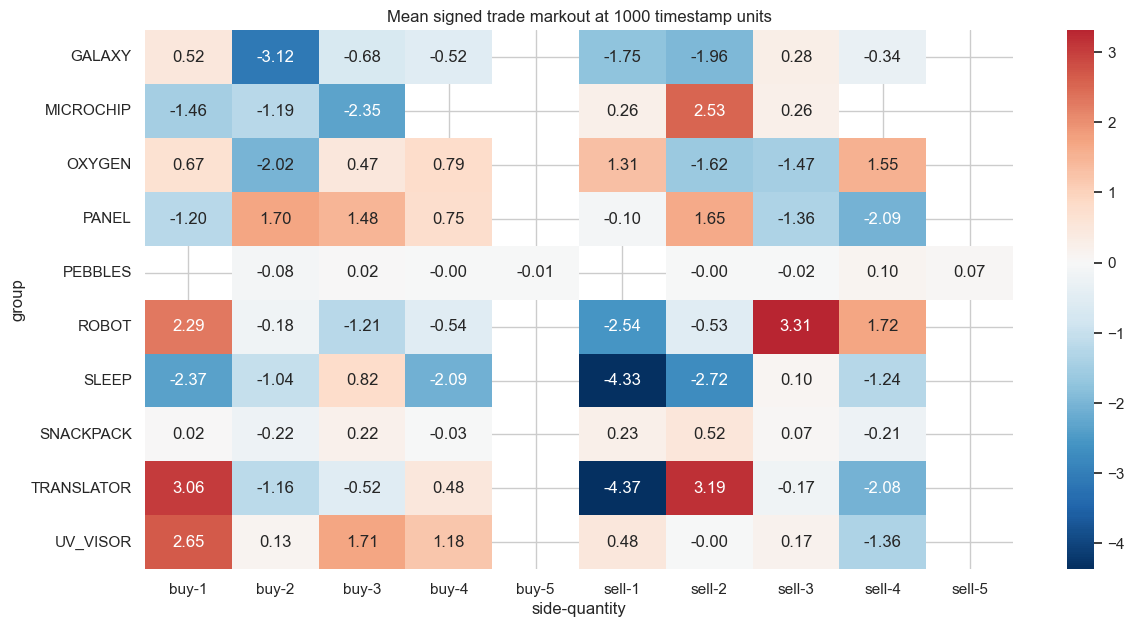

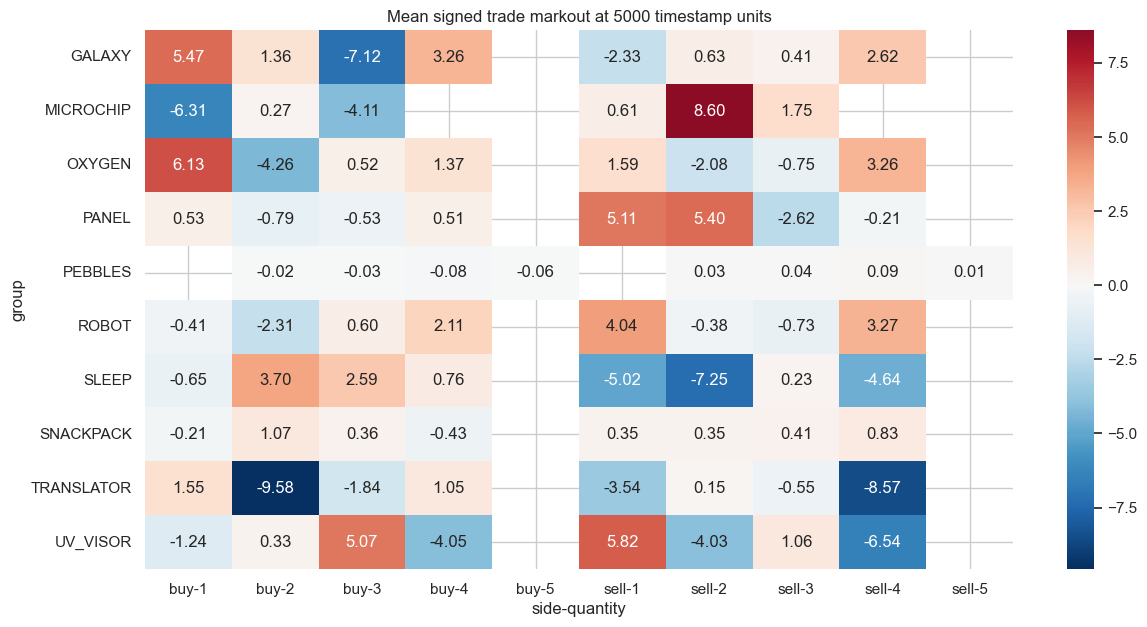

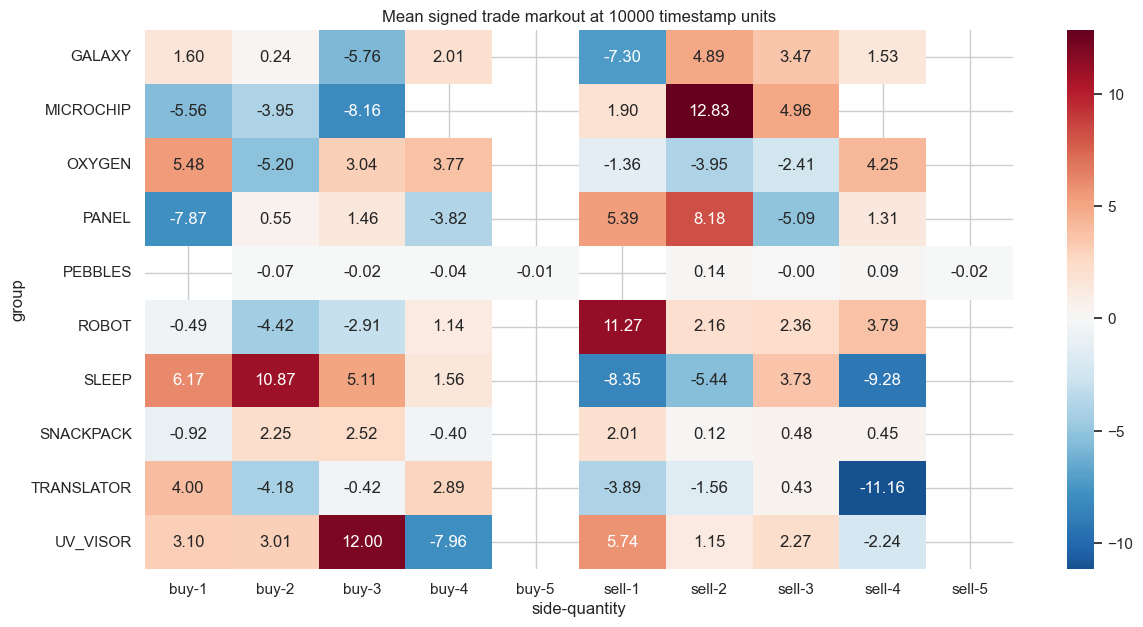

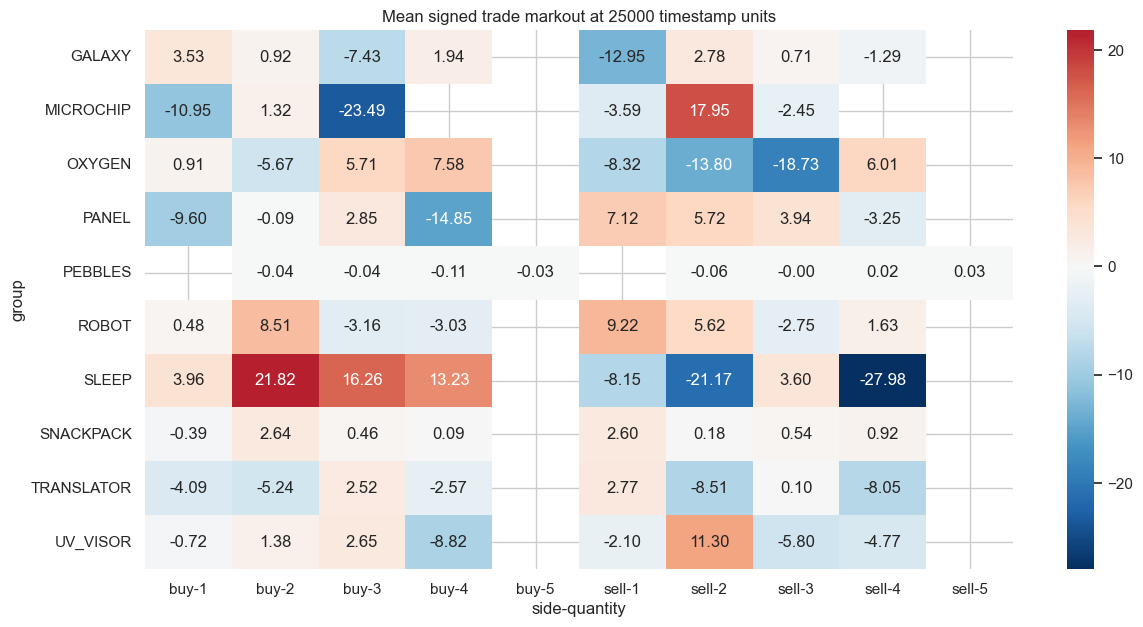

In [3]:

def mid_at_or_before(symbol, ts):
    idx = mids.index[mids.index <= ts]
    if len(idx) == 0:
        return np.nan
    return mids.loc[idx[-1], symbol]

lookaheads = [100, 500, 1000, 5000, 10000, 25000]
rows = []
for row in tr.itertuples(index=False):
    if row.side not in ("buy", "sell"):
        continue
    direction = 1 if row.side == "buy" else -1
    before = row.mid_price
    for h in lookaheads:
        after = mid_at_or_before(row.symbol, row.global_ts + h)
        rows.append({
            "global_ts": row.global_ts,
            "group": row.group,
            "symbol": row.symbol,
            "side": row.side,
            "quantity": row.quantity,
            "lookahead": h,
            "signed_markout": direction * (after - before),
            "raw_move": after - before,
        })
mark = pd.DataFrame(rows)
score = mark.groupby(["group","side","quantity","lookahead"]).agg(
    events=("signed_markout","size"),
    mean_markout=("signed_markout","mean"),
    median_markout=("signed_markout","median"),
    hit_rate=("signed_markout", lambda x: (x > 0).mean()),
    t=("signed_markout", lambda x: x.mean() / (x.std(ddof=1) / np.sqrt(len(x))) if len(x) > 2 and x.std(ddof=1) > 0 else np.nan),
).reset_index().sort_values("t", ascending=False)
display(score[score.events >= 50].head(60))

for h in lookaheads:
    piv = score[(score.events >= 50) & (score.lookahead == h)].pivot_table(index="group", columns=["side","quantity"], values="mean_markout")
    plt.figure(figsize=(14, 7))
    sns.heatmap(piv, center=0, cmap="RdBu_r", annot=True, fmt=".2f")
    plt.title(f"Mean signed trade markout at {h} timestamp units")
    plt.show()


## 3. Same-Timestamp Basket Events

In [4]:

event_rows = []
for ts, g in tr.groupby("global_ts"):
    sides = sorted(g.side.unique())
    syms = sorted(g.symbol.unique())
    event_rows.append({
        "global_ts": ts,
        "day": int(g.day.iloc[0]),
        "groups": "|".join(sorted(g.group.dropna().unique())),
        "n_symbols": len(syms),
        "symbols": "|".join(syms),
        "side": sides[0] if len(sides) == 1 else "mixed",
        "quantities": "|".join(map(str, sorted(g.quantity.unique()))),
        "mean_abs_edge": g.abs_edge_to_mid.mean(),
    })
events = pd.DataFrame(event_rows)
events["signature"] = events.groups + " n=" + events.n_symbols.astype(str) + " q=" + events.quantities + " side=" + events.side
display(events.groupby(["groups","n_symbols"]).size().reset_index(name="events").sort_values("events", ascending=False).head(30))
display(events.signature.value_counts().head(30).to_frame("events"))


,groups,n_symbols,events
2,GALAXY|OXYGEN|PANEL|ROBOT|SLEEP|SNACKPACK|TRAN...,40,707
5,PEBBLES,5,617
3,MICROCHIP,5,546
1,GALAXY|OXYGEN|PANEL|PEBBLES|ROBOT|SLEEP|SNACKP...,45,15
4,MICROCHIP|PEBBLES,10,12
0,GALAXY|MICROCHIP|OXYGEN|PANEL|ROBOT|SLEEP|SNAC...,45,11


,events
signature,
GALAXY|OXYGEN|PANEL|ROBOT|SLEEP|SNACKPACK|TRANSLATOR|UV_VISOR n=40 q=2 side=sell,100
MICROCHIP n=5 q=2 side=buy,99
GALAXY|OXYGEN|PANEL|ROBOT|SLEEP|SNACKPACK|TRANSLATOR|UV_VISOR n=40 q=1 side=buy,97
MICROCHIP n=5 q=2 side=sell,97
MICROCHIP n=5 q=3 side=buy,93
MICROCHIP n=5 q=1 side=sell,92
MICROCHIP n=5 q=1 side=buy,92
GALAXY|OXYGEN|PANEL|ROBOT|SLEEP|SNACKPACK|TRANSLATOR|UV_VISOR n=40 q=3 side=sell,92
GALAXY|OXYGEN|PANEL|ROBOT|SLEEP|SNACKPACK|TRANSLATOR|UV_VISOR n=40 q=4 side=buy,91


## 4. Basket Event Markouts

Measure future average mid movement over every product in the event basket.

,signature,groups,n_symbols,side,lookahead,events,mean_markout,hit_rate,t
85,GALAXY|OXYGEN|PANEL|ROBOT|SLEEP|SNACKPACK|TRAN...,GALAXY|OXYGEN|PANEL|ROBOT|SLEEP|SNACKPACK|TRAN...,40,buy,500,72,1.076215,0.625000,2.762212
126,MICROCHIP n=5 q=2 side=sell,MICROCHIP,5,sell,100,97,1.559794,0.577320,2.494082
84,GALAXY|OXYGEN|PANEL|ROBOT|SLEEP|SNACKPACK|TRAN...,GALAXY|OXYGEN|PANEL|ROBOT|SLEEP|SNACKPACK|TRAN...,40,buy,100,72,0.389236,0.625000,2.100609
130,MICROCHIP n=5 q=2 side=sell,MICROCHIP,5,sell,10000,97,13.047423,0.608247,1.992976
129,MICROCHIP n=5 q=2 side=sell,MICROCHIP,5,sell,5000,97,8.523711,0.597938,1.877651
60,GALAXY|OXYGEN|PANEL|ROBOT|SLEEP|SNACKPACK|TRAN...,GALAXY|OXYGEN|PANEL|ROBOT|SLEEP|SNACKPACK|TRAN...,40,buy,100,97,0.302964,0.525773,1.745520
127,MICROCHIP n=5 q=2 side=sell,MICROCHIP,5,sell,500,97,2.404124,0.556701,1.577278
131,MICROCHIP n=5 q=2 side=sell,MICROCHIP,5,sell,25000,97,16.511340,0.536082,1.501633
63,GALAXY|OXYGEN|PANEL|ROBOT|SLEEP|SNACKPACK|TRAN...,GALAXY|OXYGEN|PANEL|ROBOT|SLEEP|SNACKPACK|TRAN...,40,buy,5000,97,1.451675,0.546392,1.373175
224,PEBBLES n=5 q=5 side=sell,PEBBLES,5,sell,1000,87,0.073563,0.413793,1.344777


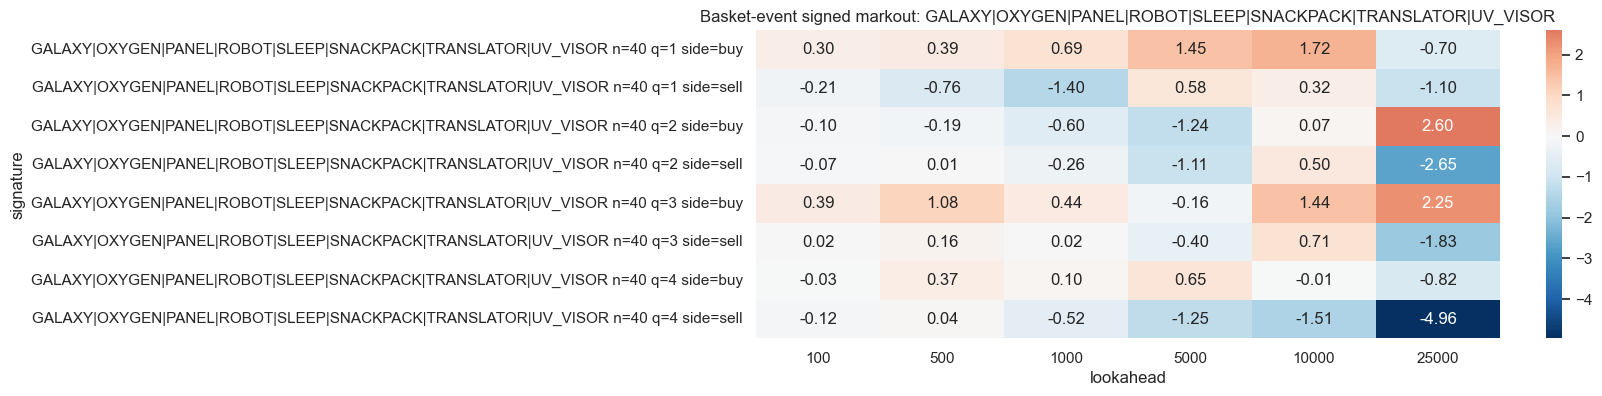

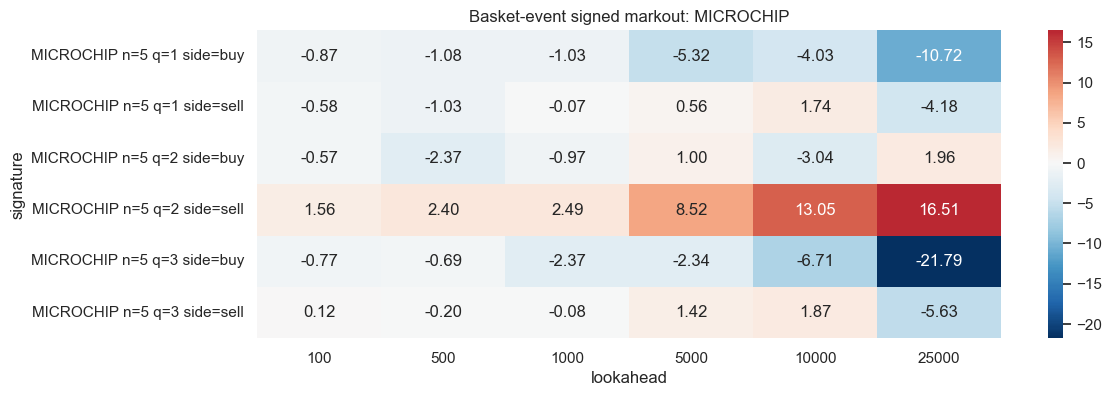

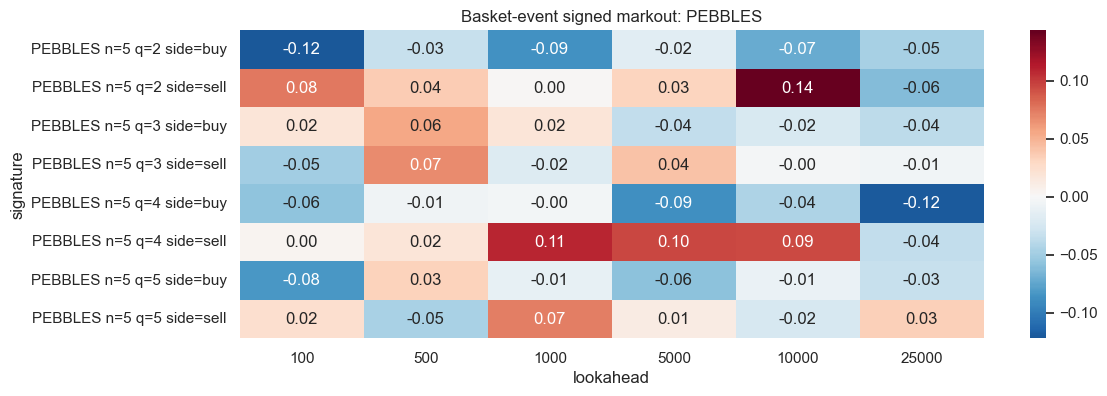

In [5]:

event_mark_rows = []
for ev in events.itertuples(index=False):
    if ev.side not in ("buy", "sell"):
        continue
    syms = ev.symbols.split("|")
    before = mids.loc[ev.global_ts, syms].mean()
    direction = 1 if ev.side == "buy" else -1
    for h in lookaheads:
        idx = mids.index[mids.index <= ev.global_ts + h]
        after = mids.loc[idx[-1], syms].mean()
        event_mark_rows.append({
            "signature": ev.signature,
            "groups": ev.groups,
            "n_symbols": ev.n_symbols,
            "side": ev.side,
            "lookahead": h,
            "signed_markout": direction * (after - before),
        })
event_mark = pd.DataFrame(event_mark_rows)
event_score = event_mark.groupby(["signature","groups","n_symbols","side","lookahead"]).agg(
    events=("signed_markout","size"),
    mean_markout=("signed_markout","mean"),
    hit_rate=("signed_markout", lambda x: (x > 0).mean()),
    t=("signed_markout", lambda x: x.mean() / (x.std(ddof=1) / np.sqrt(len(x))) if len(x) > 2 and x.std(ddof=1) > 0 else np.nan),
).reset_index().sort_values("t", ascending=False)
display(event_score[event_score.events >= 50].head(80))

for groups in event_score[event_score.events >= 50].groups.unique()[:6]:
    piv = event_score[(event_score.groups == groups) & (event_score.events >= 50)].pivot_table(index="signature", columns="lookahead", values="mean_markout")
    plt.figure(figsize=(12, max(4, len(piv) * 0.35)))
    sns.heatmap(piv, center=0, cmap="RdBu_r", annot=True, fmt=".2f")
    plt.title(f"Basket-event signed markout: {groups}")
    plt.show()


## 5. Trade Flow As Predictor Of Group Returns

Aggregate signed trade flow by group and compare it to future group-average returns.

,group,future_bucket_lag,corr,n
7,GALAXY,7,-0.064843,1468
19,SLEEP,8,-0.064149,1467
31,MICROCHIP,9,-0.058994,1466
67,TRANSLATOR,1,-0.055468,1474
99,SNACKPACK,0,-0.055302,1475
62,UV_VISOR,7,-0.054218,1468
15,SLEEP,4,0.051539,1471
16,SLEEP,5,-0.050545,1470
102,SNACKPACK,3,0.050068,1472
3,GALAXY,3,-0.047623,1472


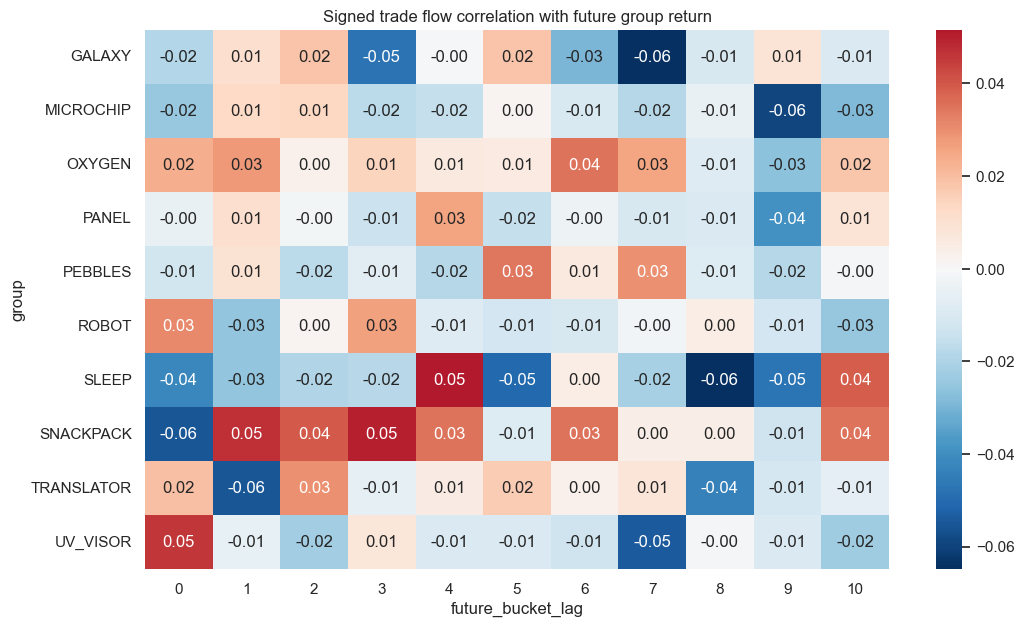

In [6]:

flow = tr[tr.side.isin(["buy","sell"])].copy()
flow["signed_qty"] = np.where(flow.side == "buy", flow.quantity, -flow.quantity)
bucket = 1000
flow["bucket"] = (flow.global_ts // bucket) * bucket
flow_g = flow.groupby(["bucket","group"]).signed_qty.sum().unstack().reindex(columns=list(GROUPS)).fillna(0)
group_mid = pd.DataFrame({g: mids[ps].mean(axis=1) for g, ps in GROUPS.items()})
group_ret = np.log(group_mid).diff().rename(columns=lambda c: c)
group_ret_b = group_ret.groupby((group_ret.index // bucket) * bucket).sum().reindex(flow_g.index).fillna(0)

flow_scores = []
for g in GROUPS:
    for lag in range(0, 11):
        sig = flow_g[g]
        fut = group_ret_b[g].shift(-lag)
        x = pd.concat([sig, fut], axis=1).dropna()
        if x.iloc[:,0].std() == 0:
            continue
        flow_scores.append({
            "group": g,
            "future_bucket_lag": lag,
            "corr": x.iloc[:,0].corr(x.iloc[:,1]),
            "n": len(x),
        })
flow_scores = pd.DataFrame(flow_scores).sort_values("corr", key=lambda s: s.abs(), ascending=False)
display(flow_scores.head(40))

plt.figure(figsize=(12, 7))
piv = flow_scores.pivot(index="group", columns="future_bucket_lag", values="corr")
sns.heatmap(piv, center=0, cmap="RdBu_r", annot=True, fmt=".2f")
plt.title("Signed trade flow correlation with future group return")
plt.show()
